# **STEP 1: IMPORT LIBRARIES**

In [8]:
# Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,f1_score,accuracy_score,recall_score,precision_score,roc_curve,roc_auc_score
from sklearn.model_selection import train_test_split,GridSearchCV

In [9]:
# Loading the data
df = pd.read_csv('E:\FDS\creadit risk\credit_risk_dataset.csv')
df.head()

<>:2: SyntaxWarning: invalid escape sequence '\F'
<>:2: SyntaxWarning: invalid escape sequence '\F'
C:\Users\dell\AppData\Local\Temp\ipykernel_1804\1960699615.py:2: SyntaxWarning: invalid escape sequence '\F'
  df = pd.read_csv('E:\FDS\creadit risk\credit_risk_dataset.csv')


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [10]:
# Data description
df.info()
print("\nDescriptive summary")
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB

Descriptive summary


,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


In [11]:
# Duplicated test
df.duplicated().sum()

np.int64(165)

In [12]:
# Eliminating duplicates
df.drop_duplicates(inplace= True)

In [13]:
# Calculate missing value percentage
formatted_percentage = ((df.isna().sum() / len(df)) * 100).round(2).astype(str) + "%"
print(formatted_percentage)

person_age                     0.0%
person_income                  0.0%
person_home_ownership          0.0%
person_emp_length             2.74%
loan_intent                    0.0%
loan_grade                     0.0%
loan_amnt                      0.0%
loan_int_rate                 9.55%
loan_status                    0.0%
loan_percent_income            0.0%
cb_person_default_on_file      0.0%
cb_person_cred_hist_length     0.0%
dtype: object


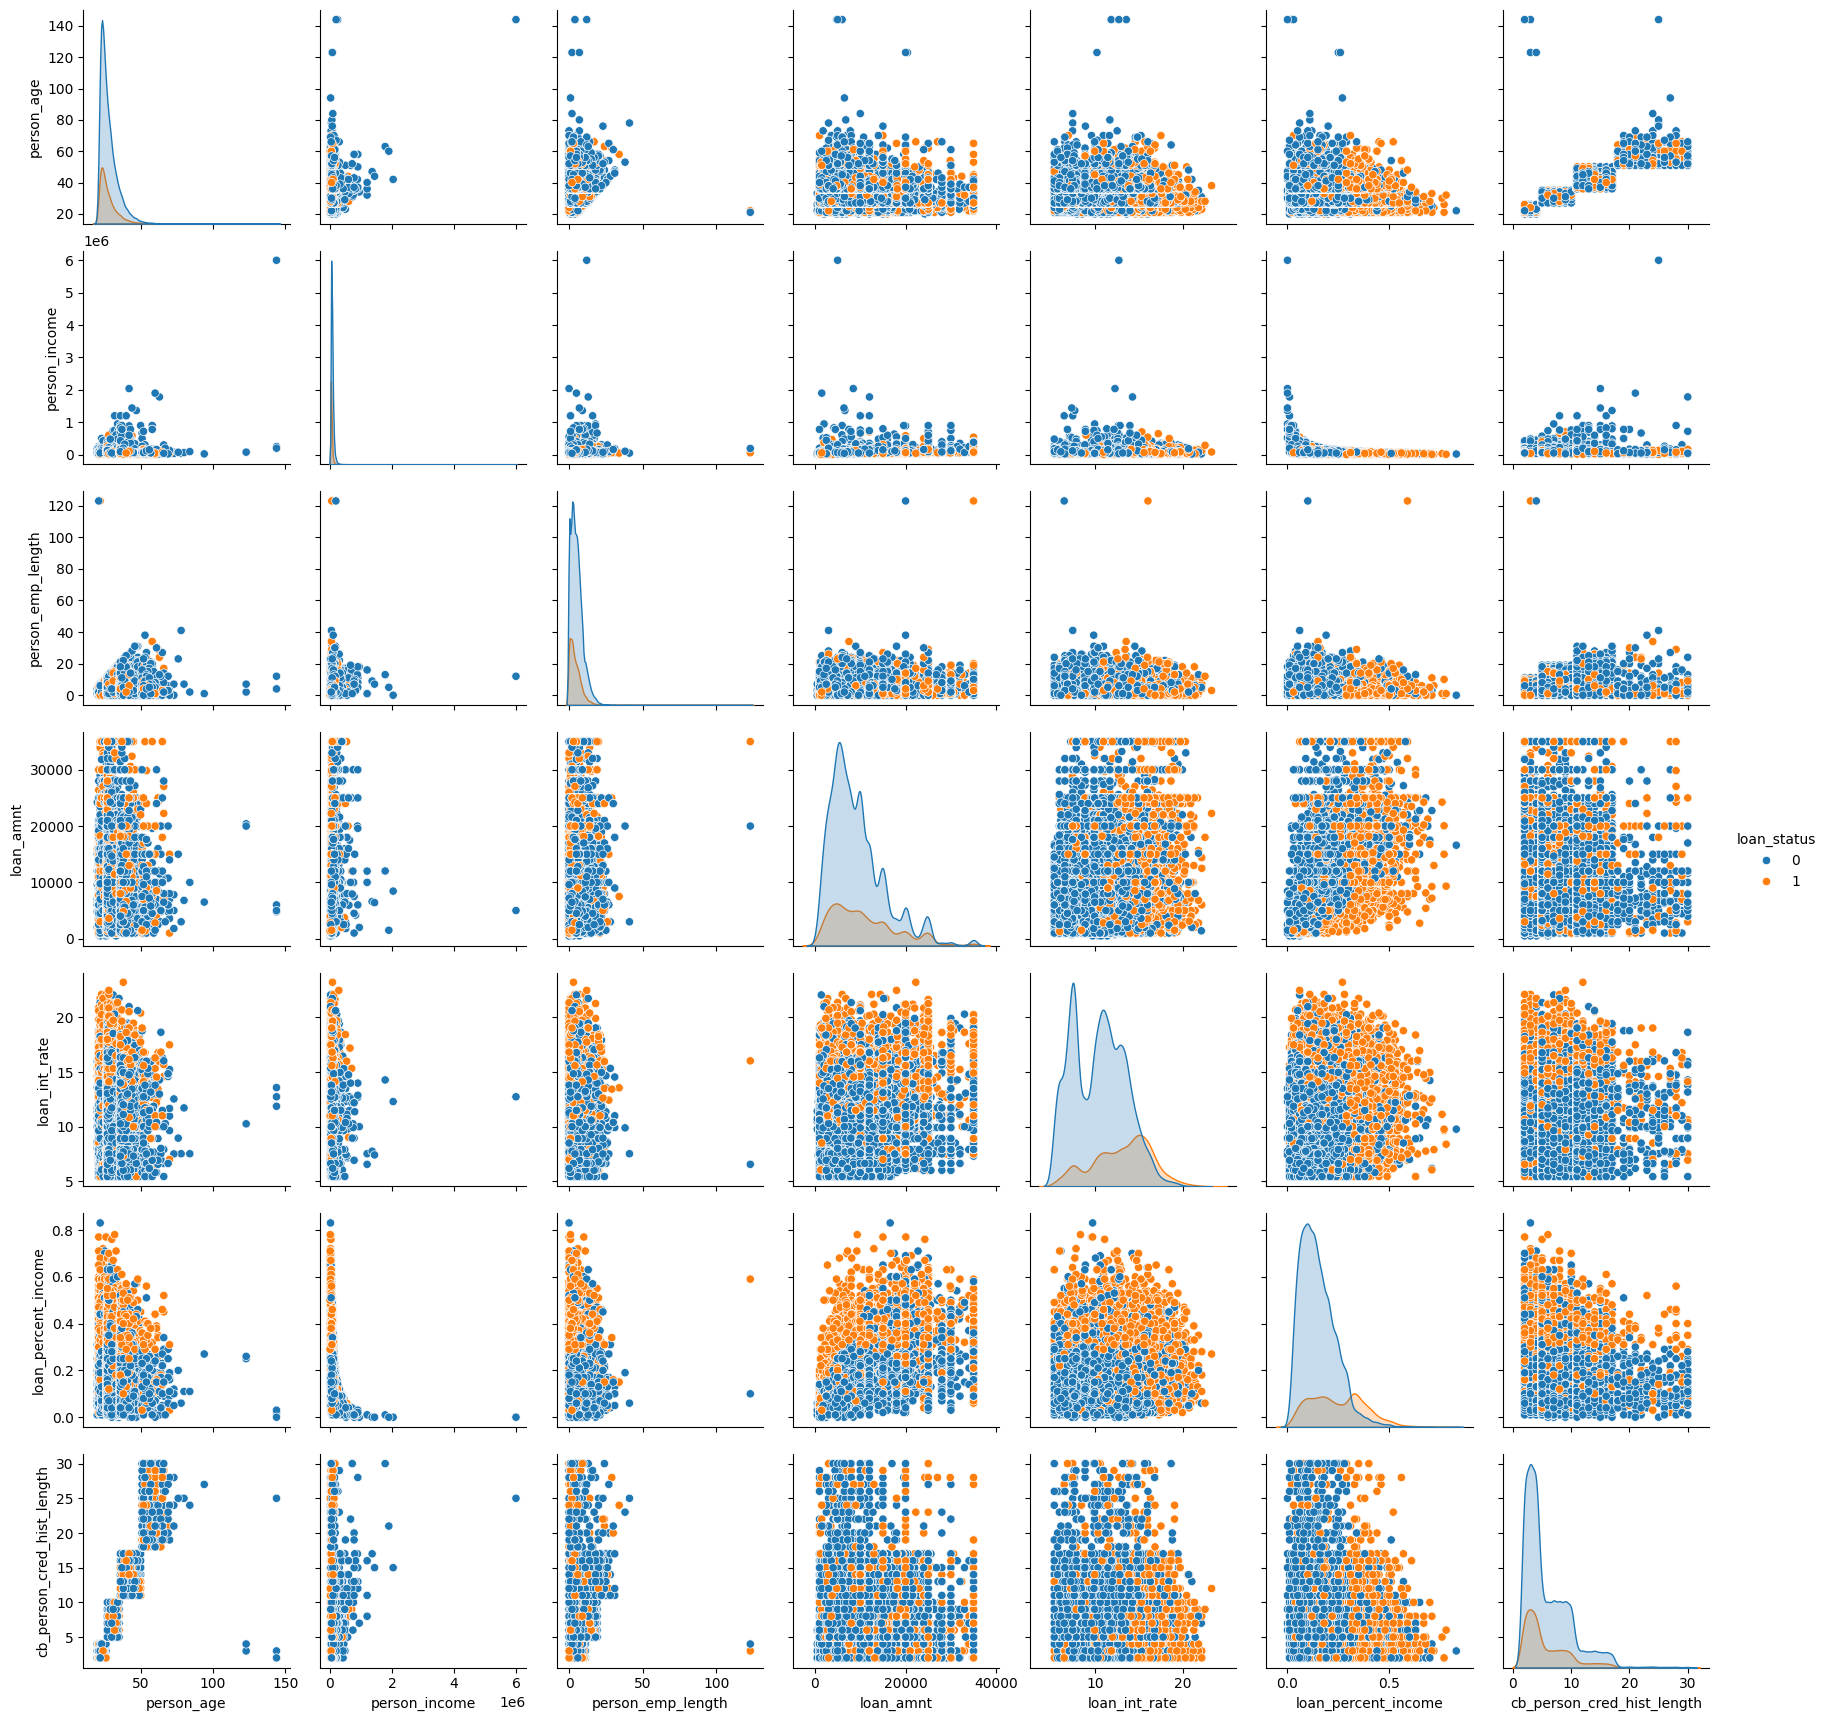

In [14]:
sns.pairplot(df,hue='loan_status') 

<Axes: >

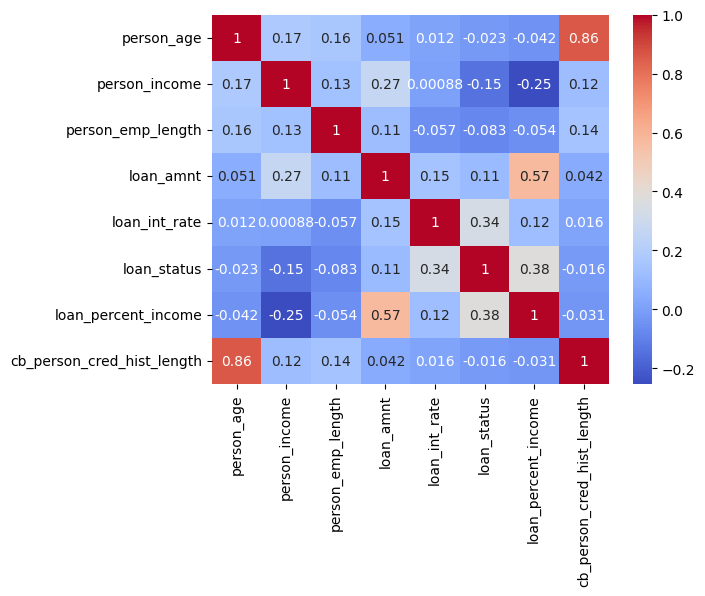

In [15]:
sns.heatmap(df.corr(numeric_only=True),cmap='coolwarm',annot=True)

<Axes: xlabel='loan_intent', ylabel='count'>

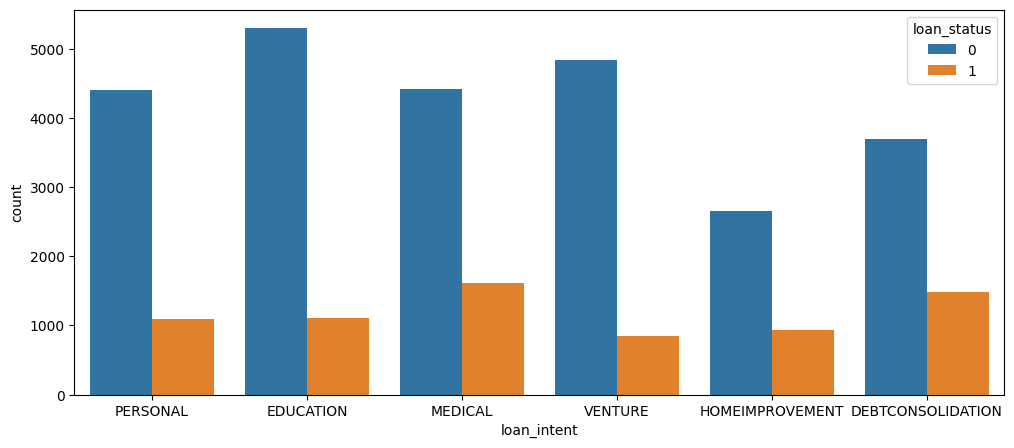

In [16]:
plt.figure(figsize=(12,5))
sns.countplot(data=df,x='loan_intent',hue='loan_status')

<Axes: xlabel='cb_person_cred_hist_length', ylabel='Count'>

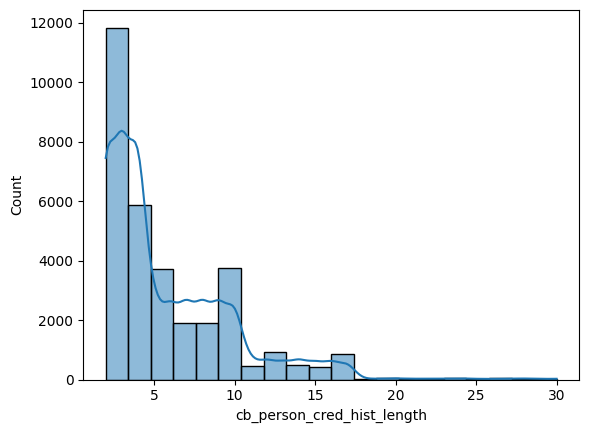

In [17]:
sns.histplot(df['cb_person_cred_hist_length'],bins=20,kde=True)

C:\Users\dell\AppData\Local\Temp\ipykernel_1804\674995523.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='loan_status',palette='rainbow')


<Axes: xlabel='loan_status', ylabel='count'>

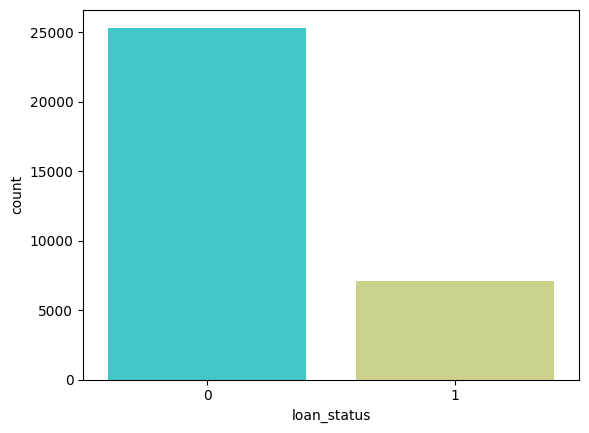

In [18]:
sns.countplot(data=df,x='loan_status',palette='rainbow')

In [19]:
df['loan_status'].sum()/df['loan_status'].count()*100

np.float64(21.868830207305034)

This shows that our data is kind of non-uniformly distributed

# **Data Preprocessing**

In [20]:
dfcpy=df.copy()

define the function to fill the missing values and then apply it

In [21]:
def fill_length(x):
    if x.isnull().any():
        return round(0.1631056*x[0])
    else:
        return x[1]

In [22]:
dfcpy['person_emp_length']=df[['person_age','person_emp_length']].apply(fill_length,axis=1)

C:\Users\dell\AppData\Local\Temp\ipykernel_1804\1569467088.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return x[1]
C:\Users\dell\AppData\Local\Temp\ipykernel_1804\1569467088.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return round(0.1631056*x[0])


 fill the loab_int_rate missing values

C:\Users\dell\AppData\Local\Temp\ipykernel_1804\403403221.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfcpy,x='loan_grade',y='loan_int_rate',palette='rainbow')


<Axes: xlabel='loan_grade', ylabel='loan_int_rate'>

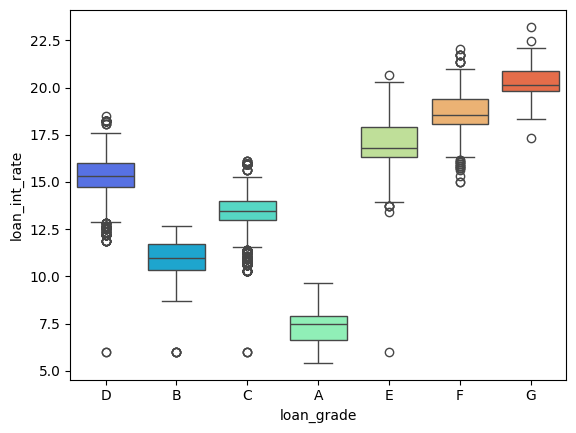

In [23]:
sns.boxplot(data=dfcpy,x='loan_grade',y='loan_int_rate',palette='rainbow')

sns.boxplot(data=dfcpy,x='loan_grade',y='loan_int_rate',palette='rainbow')

In [24]:
dfcpy.groupby('loan_grade').mean(numeric_only=True)['loan_int_rate']

loan_grade
A     7.328423
B    10.995756
C    13.464579
D    15.360698
E    17.008409
F    18.609159
G    20.251525
Name: loan_int_rate, dtype: float64

In [25]:
def fill_rate(x):
    if x.isnull().any():
        if x[0]=='A':
            return 7.33
        elif x[0]=='B':
            return 11.00
        elif x[0]=='C':
            return 13.46
        elif x[0]=='D':
            return 15.36
        elif x[0]=='E':
            return 17.01
        elif x[0]=='F':
            return 18.61
        else:
            return 20.25
    else:
        return x[1]

This function will fill the missing interest rate with the mean value for the loan_grade of that case

In [26]:
dfcpy['loan_int_rate']=df[['loan_grade','loan_int_rate']].apply(fill_rate,axis=1)

C:\Users\dell\AppData\Local\Temp\ipykernel_1804\790178786.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return x[1]
C:\Users\dell\AppData\Local\Temp\ipykernel_1804\790178786.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if x[0]=='A':
C:\Users\dell\AppData\Local\Temp\ipykernel_1804\790178786.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  elif x[0]=='B':
C:\Users\dell\AppData\Local\Temp\ipykernel_1804\790178786.py:7:

In [27]:
dfcpy.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

All the missing values are filled now

In [28]:
list(dfcpy.select_dtypes('object').columns)

['person_home_ownership',
 'loan_intent',
 'loan_grade',
 'cb_person_default_on_file']

We have few features with non-numerical data types. Most of the machine learning models require numerical data. So we will convert them into numerical data using get_dummies function of pandas library.

In [29]:
own_dummy=pd.get_dummies(dfcpy['person_home_ownership'],drop_first=True)
intent_dummy=pd.get_dummies(dfcpy['loan_intent'],drop_first=True)
grade_dummy=pd.get_dummies(dfcpy['loan_grade'],drop_first=True)
default_dummy=pd.get_dummies(dfcpy['cb_person_default_on_file'],drop_first=True)

In [30]:
dfcpy=pd.concat([dfcpy,own_dummy,intent_dummy,grade_dummy,default_dummy],axis=1)

Now, let's remove the old non-numerical columns

In [31]:
dfcpy.drop(list(dfcpy.select_dtypes('object').columns),axis=1,inplace=True)

# **Train-Test-Split**

In [32]:
X=dfcpy.drop('loan_status',axis=1)
y=dfcpy['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

We have to scale the data for better performance

In [33]:
scaler=StandardScaler()
X_train=pd.DataFrame(scaler.fit_transform(X_train),columns=X_train.columns,index=X_train.index)
X_test=pd.DataFrame(scaler.transform(X_test),columns=X_test.columns,index=X_test.index)

# **Machine Learning and Evaluation**

This code will train each model with training data and then predict the results for test data

In [34]:
models=[LogisticRegression(),KNeighborsClassifier(),DecisionTreeClassifier(),RandomForestClassifier(),XGBClassifier()]
f1=[]
accuracy=[]
recall=[]
precision=[]
for model in models:
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    f1.append(f1_score(y_test,pred))
    accuracy.append(accuracy_score(y_test,pred))
    recall.append(recall_score(y_test,pred))
    precision.append(precision_score(y_test,pred))

In [35]:
results=pd.DataFrame(index=['Logistic Regression','KNN','Decision Tree','Random Forest','XGBoost'])

In [36]:
results['F1 score']=f1
results['Accuracy']=accuracy
results['Recall']=recall
results['Precision']=precision

<Axes: >

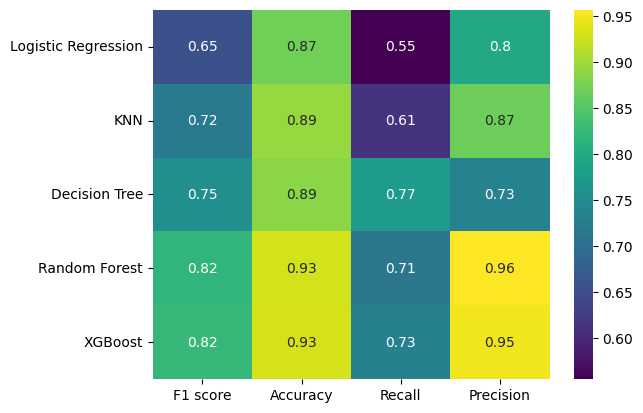

In [37]:
sns.heatmap(results,cmap='viridis',annot=True)

Here we can see that Random Forest, XGBoost, LightGBM performed better than others. XGBoost and LightGBM works really well on non-uniform data.

# Grid Search on Random Forest

In [38]:
rfc=RandomForestClassifier()
param_grid = {
    'n_estimators': [300,400,500]
}

grid_search = GridSearchCV(estimator = rfc, param_grid = param_grid, verbose = 2)
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END ...................................n_estimators=300; total time=   8.6s
[CV] END ...................................n_estimators=300; total time=   9.2s
[CV] END ...................................n_estimators=300; total time=   7.8s
[CV] END ...................................n_estimators=300; total time=   6.7s
[CV] END ...................................n_estimators=300; total time=   7.0s
[CV] END ...................................n_estimators=400; total time=   9.1s
[CV] END ...................................n_estimators=400; total time=   9.1s
[CV] END ...................................n_estimators=400; total time=   9.1s
[CV] END ...................................n_estimators=400; total time=   8.8s
[CV] END ...................................n_estimators=400; total time=   9.1s
[CV] END ...................................n_estimators=500; total time=  11.4s
[CV] END ...................................n_est

,estimator,RandomForestClassifier()
,param_grid,"{'n_estimators': [300, 400, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,500


In [39]:
grid_search.best_params_

{'n_estimators': 500}

In [40]:
pred=grid_search.predict(X_test)

In [41]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.92      0.99      0.96      7568
           1       0.96      0.72      0.82      2157

    accuracy                           0.93      9725
   macro avg       0.94      0.85      0.89      9725
weighted avg       0.93      0.93      0.93      9725



Grid Search has improved the performance for Random Forest

# Grid Search on XGBoost

In [42]:
xgb=XGBClassifier()
param_grid = {
    'n_estimators': [100,200,300],
    'learning_rate': [0.1,0.05,0.025]
}

grid_search = GridSearchCV(estimator = xgb, param_grid = param_grid, verbose = 2)
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ................learning_rate=0.1, n_estimators=100; total time=   0.2s
[CV] END ................learning_rate=0.1, n_estimators=100; total time=   0.2s
[CV] END ................learning_rate=0.1, n_estimators=100; total time=   0.2s
[CV] END ................learning_rate=0.1, n_estimators=100; total time=   0.2s
[CV] END ................learning_rate=0.1, n_estimators=100; total time=   0.2s
[CV] END ................learning_rate=0.1, n_estimators=200; total time=   0.3s
[CV] END ................learning_rate=0.1, n_estimators=200; total time=   0.4s
[CV] END ................learning_rate=0.1, n_estimators=200; total time=   0.4s
[CV] END ................learning_rate=0.1, n_estimators=200; total time=   0.4s
[CV] END ................learning_rate=0.1, n_estimators=200; total time=   0.8s
[CV] END ................learning_rate=0.1, n_estimators=300; total time=   1.0s
[CV] END ................learning_rate=0.1, n_est

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.1, 0.05, ...], 'n_estimators': [100, 200, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [ ]:
pred=grid_search.predict(X_test)

[0 0 0 ... 0 0 0]


In [44]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      7568
           1       0.96      0.73      0.83      2157

    accuracy                           0.93      9725
   macro avg       0.95      0.86      0.89      9725
weighted avg       0.94      0.93      0.93      9725



Grid Search has improved the performance for XGBoost

# Conclusion

The dataset containing 11 financial ratios and a 'loan_status' target variable was loaded into a pandas DataFrame. The dataset has 32581 records and 12 features. We performed exploratory data analysis(EDA) to visually understand the data. The given data had some missing values. We filled them with different techniques. Also the data had some non-numerical features. We converted then into numerical data using get_dummies() function. Then we performed train-test-split. We applied different machine learning models and evaluated the performances. Random Forest, XGBoost and  have done very well despite the non-uniformly distributed data. XGBoost are two most used ML algorithms in Data Science world. Then we performed Grid Search to find best hyperparameters and to improve model's performance. Also we evaluated some models using ROC curve and ROC-AUC score.

# Future

I think we can use some more ml models,use different techniques for replace missing values also can use different technique for hyprperameter tunning can use class weights

oversampling (SMOTE)

threshold tuning

different models.

# Learnings

While collecting DATA 
1. when I start the project I want to do web sraping for collecting the data but as I learn about it I get to know that I need to learn more to do web scraping.
2. understain the data before come to the coading part (when first I start I was like just collect the data and peform some ml operation to it but the reality is if you don't understant what is inside your data and what are your requements you can't go fourther it feels like you are stuck and don't know where to go.)
3. Check you data set (when first I pick the data from kaggle it was german data set but first it is too small and second the coloums in thst where non relevent,my second dataset was lone data set in which your too small that any prediction can not be possible from that)
4. use notebook before jupiter notebook (first prepair a plain that what techniques you want to use to clean the dataset and what are the models you want to apply on it you can create a rough mind mape for all your work flow) 